Análisis exploratorio inicial de la base, caracterizando sus atributos y describiendo su comportamiento, distribución de variables, presencia de outliers, valores nulos y demás particularidades que crea de relevancia para el análisis.

### Campos del Recurso y Clasificación Estadística

Esta tabla resume la descripción de cada variable y su clasificación estadística para el análisis.

| Variable | Descripción | Tipo Estadístico | Nivel |
| :--- | :--- | :--- | :--- |
| **long** | Longitud geográfica (X coordinate). | Cuantitativa | Continua |
| **lat** | Latitud geográfica (Y coordinate). | Cuantitativa | Continua |
| **nro_registro** | Número de registro único del árbol. | Cualitativo | Nominal |
| **tipo_activ** | Tipo de actividad o clasificación del árbol. | Cualitativo | Nominal |
| **comuna** | Número de la comuna. | Cualitativo | Nominal |
| **manzana** | Identificador de la manzana. | Cualitativo | Nominal |
| **calle_nombre** | Nombre de la calle. | Cualitativo | Nominal |
| **calle_altura** | Altura de la calle (numérico). | Cuantitativo | Discreto |
| **calle_chapa** | Número de chapa de la calle más cercano. | Cuantitativo | Discreto |
| **direccion_normalizada** | Dirección normalizada. | Cualitativo | Nominal |
| **ubicacion** | Información adicional sobre la ubicación. | Cualitativo | Nominal |
| **nombre_cientifico** | Nombre científico de la especie. | Cualitativo | Nominal |
| **ancho_acera** | Ancho de la acera, en metros. | Cuantitativo | Continuo |
| **estado_plantera** | Estado de la plantación. | Cualitativo | Nominal |
| **ubicacion_plantera** | Condición de la ubicación de la plantación. | Cualitativo | Nominal |
| **nivel_plantera** | Nivel de la plantación respecto al suelo. | Cualitativo | Nominal |
| **diametro_altura_pecho** | Diámetro del árbol a la altura del pecho, en centímetros. | Cuantitativo | Continuo |
| **altura_arbol** | Altura del árbol en metros. | Cuantitativo | Continuo |

Todas las variables son de tipo String originalmente.

In [21]:

from wget import download
from os import path 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, chi2_contingency,levene, shapiro,probplot
#from statsmodels.stats.multicomp import pairwise_tukeyhsd

#abrimos el archivo de base de datos
if not path.exists("arbolado-publico-lineal-2017-2018.csv"):
  download("https://cdn.buenosaires.gob.ar/datosabiertos/datasets/atencion-ciudadana/arbolado-publico-lineal/arbolado-publico-lineal-2017-2018.csv")
else:
  print("El archivo ya existe")

dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")

dataset.info()
#dataset.head()
#dataset.describe()
dataset["estado_plantera"].value_counts()
filas_nan = dataset[dataset[["lat","manzana","calle_nombre"]].isna().all(axis=1)]
#print(filas_nan[["comuna", "calle_altura", "lat", "manzana","calle_chapa"]])
#cantidad_por_comuna = filas_nan['comuna'].value_counts()
dataset["nombre_cientifico"].value_counts()
#print(cantidad_por_comuna)

El archivo ya existe


C:\Users\Eliana\AppData\Local\Temp\ipykernel_3840\3247796767.py:20: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   nro_registro           370180 non-null  object 
 3   tipo_activ             370180 non-null  object 
 4   comuna                 370180 non-null  int64  
 5   manzana                224140 non-null  object 
 6   calle_nombre           370087 non-null  object 
 7   calle_altura           364677 non-null  object 
 8   calle_chapa            363721 non-null  object 
 9   direccion_normalizada  355941 non-null  object 
 10  ubicacion              361884 non-null  object 
 11  nombre_cientifico      370180 non-null  object 
 12  ancho_acera            367083 non-null  object 
 13  estado_plantera        370180 non-null  object 
 14  ubicacion_plantera     368776 non-nu

nombre_cientifico
Fraxinus pennsylvanica    133609
Platanus x acerifolia      32319
Ficus benjamina            22508
Tilia x moltkei            15605
Melia azedarach            14901
                           ...  
Juglans mandshurica            1
Osmanthus fragrans             1
Sterculia monosperma           1
Ficus microcarpa               1
Pyracantha coccinea            1
Name: count, Length: 431, dtype: int64

### LIMPIEZA 

tipo_activ: Pasamos todo a minuculas y quitamos los espacios en blanco de la palabra Lineal 
// cuando saber si usamos 0 y 1 para una variable? se podria usar aca?
que hacemos con calle?
Decidimos eliminar esta columna. No nos aporta nada relevante para las hipotesis que planteamos y tampoco los valores son variables. Tenemos la mayoria de las muestras LINEAL y la otra opcion (CALLE) ni siquiera sabemos que significa

manzana: Reconoce el tipo como string y signos, simbolos, etc.
// que hacemos con los nulos?? y las letras NO habia que borrarlas todavia, que hacemos con estas?
capaz pueden ser manzanas repetidas(revisarlo con lat y long)

calle_altura: Busco si no hay valores decimales, al no encontrar paso los datos a int64 q acepta nulos? o reemplazo los nulos con algo, por ej con 0?
//que hacemos con los nulos aca tmb?

calle_chapa: aca pasa lo mismo que con la var anterior

direccion_normalizada: pasamos todo a minuscula y sacamos los espacios en blanco, comas y simbolos
//ver que hacer con los datos, separamos calle y altura en columnas distintas?

ubicacion: pasamos todo a minusculas. 
//tenemos que cambiar todo lo que no sea exacta por no exacta? o que hacemos?

nombre_cientifico: pasamos todo a minuscula, nada mas para limpiar

estado_plantera: paso a minusculas y borro las palabras que estan demas.
//que hacemos con las que tienen dos cosas? hacemos dos columnas? una para saber si esta ocupada y otra para saber si esta cerrada

ubicacion_plantera: paso a minusculas, agrego las letras que faltan
//que hacemos con las que tieen mas de una cosa?

nivel_plantera: paso a minusculas, elimino espacios y agrupo valores como EL,elevadas,elevado,... por elevada. cambio los strings "nan" y "obs" por NaN de pandas
//que hacemos con ochava???

diametro_altura_pecho: no modificamos nada. todos los que no son enteros son NaN
//habria que cambiarlo? (como para eliminar el .0 que es innecesario si son todos enteros o nulos)

altura_arbol: lo mismo que diametro_altura_pecho

In [22]:
copiaDataset= dataset

copiaDataset=copiaDataset.drop(columns=["tipo_activ"])

copiaDataset["manzana"] = copiaDataset["manzana"].astype(str).str.strip().str.lower()
copiaDataset["manzana"] = copiaDataset["manzana"].str.replace(r'[^a-z0-9]', '',  regex=True)
copiaDataset["manzana"].value_counts()

copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].astype(str).str.strip().str.lower()
copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].str.replace(r'[^a-z ]', '',  regex=True)
#copiaDataset["calle_nombre"].value_counts()

copiaDataset["calle_altura"] = pd.to_numeric(copiaDataset["calle_altura"], errors='coerce')#conierto la col en numerica, todo en float y si no en NaN
(copiaDataset["calle_altura"] % 1 != 0).any()#veo si hay valores decimales
#copiaDataset['calle_altura'] = copiaDataset['calle_altura'].astype(float).astype('Int64') 
copiaDataset["calle_altura"] = (copiaDataset["calle_altura"].fillna(0).astype(float).astype(int))
#copiaDataset["calle_altura"].value_counts()

copiaDataset["direccion_normalizada"] = (copiaDataset["direccion_normalizada"].astype(str).str.strip().str.lower())
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r',', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'[^a-z0-9áéíóúñ ]', '', regex=True)
# Extraer altura (último número de la cadena)
copiaDataset["altura"] = copiaDataset["direccion_normalizada"].str.extract(r'(\d+)$')
# Quitar la altura de la dirección para quedarte con el nombre limpio
copiaDataset["calle"] = copiaDataset["direccion_normalizada"].str.replace(r'\s*\d+\s*$', '', regex=True)
#copiaDataset["direccion_normalizada"].value_counts()
#copiaDataset[['direccion_normalizada', 'calle', 'altura']].head(10)

copiaDataset["ubicacion"] = copiaDataset["ubicacion"].astype(str).str.strip().str.lower()
#copiaDataset["ubicacion"].value_counts()

copiaDataset["nombre_cientifico"] = copiaDataset["nombre_cientifico"].astype(str).str.strip().str.lower()
#copiaDataset["nombre_cientifico"].value_counts()

copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].astype(str).str.strip().str.lower()
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('cantero ', '', regex=False)
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('ocupado', 'ocupada', regex=False)
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace("parc.","parcialmente", regex=False)

copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["estado_plantera"].value_counts()

copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].astype(str).str.strip().str.lower()
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["elevadas","eleveda","el","elevado"],"elevada")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["bn","bajo bivel","baja nivel","reducida"],"bajo nivel")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["an","regular"],"a nivel")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["nan","obs: no tiene plantera definida"],np.nan)
#copiaDataset["nivel_plantera"].value_counts()
#copiaDataset["nivel_plantera"].isna().sum()

# Filtrar solo los valores que no son enteros y mostrar solo la columna
no_enteros = copiaDataset.loc[copiaDataset["diametro_altura_pecho"] % 1 != 0, "diametro_altura_pecho"]
#print(no_enteros)
#copiaDataset["diametro_altura_pecho"].isna().sum()

#print(copiaDataset.loc[copiaDataset["altura_arbol"] % 1 != 0, "altura_arbol"])
#copiaDataset["altura_arbol"].isna().sum()
copiaDataset["estado_plantera"].value_counts()


estado_plantera
ocupada                              330982
sobreocupada                          38549
subocupada                              532
parcialmente cerrada                     76
cerrada                                  32
sobreocupada parcialmente cerrada         5
vacía                                     4
Name: count, dtype: int64

### Análisis Univariado

#### Hipotesis 1
- Las comunas del norte de la Ciudad de Buenos Aires (12, 13 y 14) 
presentan mayor densidad de árboles por superficie urbana que las comunas del sur (4, 8 y 9).

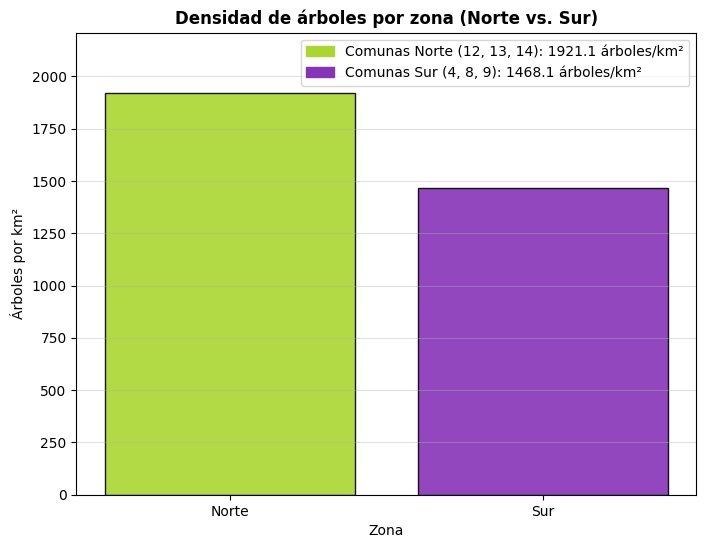

In [23]:
superficies = {     #en km²
    1: 17.9,  2: 6.3,  3: 6.4,  4: 22.7,  5: 6.7,
    6: 6.9,  7: 12.4, 8: 22.5, 9: 16.6, 10: 12.6,
    11: 14.1, 12: 15.7, 13: 15.0, 14: 15.9, 15: 14.3
}

# Asumo que 'copiaDataset' está disponible.
datasetH1 = copiaDataset[["comuna"]].copy()

# Contar cantidad de árboles por comuna
arboles_por_comuna = datasetH1.groupby("comuna").size().reset_index(name="cantidad_arboles")
# Agregar la superficie de cada comuna
arboles_por_comuna["superficie"] = arboles_por_comuna["comuna"].map(superficies)
# Calcular densidad de árboles por km²
arboles_por_comuna["densidad_arboles"] = arboles_por_comuna["cantidad_arboles"] / arboles_por_comuna["superficie"]

# Definir grupos
grupo_norte = [12, 13, 14]
grupo_sur = [4, 8, 9]

# Clasificar cada comuna en una zona
def asignar_zona(comuna):
    if comuna in grupo_norte:
        return "Norte"
    elif comuna in grupo_sur:
        return "Sur"
    return None  # evita NaNs en comunas que no pertenecen a la hipótesis

arboles_por_comuna["zona"] = arboles_por_comuna["comuna"].apply(asignar_zona)

# Agrupar por zona sumando árboles y superficie
zona_resumen = arboles_por_comuna.groupby("zona").agg(
    arboles_totales=("cantidad_arboles", "sum"),
    superficie_total=("superficie", "sum")
).reset_index()

# Calcular densidad por zona
zona_resumen["densidad"] = zona_resumen["arboles_totales"] / zona_resumen["superficie_total"]

# Extracción de la densidad para el Norte
densidad_norte = zona_resumen[zona_resumen["zona"] == "Norte"]["densidad"].iloc[0]
# Extracción de la densidad para el Sur
densidad_sur = zona_resumen[zona_resumen["zona"] == "Sur"]["densidad"].iloc[0]

# Colores
color_norte = "#AAD630"
color_sur = "#8733B8"
colores = [color_norte, color_sur]

# Gráfico
plt.figure(figsize=(8,6))
plt.bar(
    zona_resumen["zona"],
    zona_resumen["densidad"],
    color=colores,
    edgecolor="black",
    alpha=0.9
)

# Leyenda
norte_patch = mpatches.Patch(
    color=color_norte, 
    label=f'Comunas Norte (12, 13, 14): {densidad_norte:.1f} árboles/km²'
)
sur_patch = mpatches.Patch(
    color=color_sur, 
    label=f'Comunas Sur (4, 8, 9): {densidad_sur:.1f} árboles/km²'
)

# Añade la leyenda al gráfico
plt.legend(handles=[norte_patch, sur_patch], loc='upper right')

# Títulos y Ejes
plt.title("Densidad de árboles por zona (Norte vs. Sur)", fontweight="bold")
plt.xlabel("Zona")
plt.ylabel("Árboles por km²")
plt.grid(axis='y', linestyle='-', alpha=0.4)
plt.ylim(0, zona_resumen["densidad"].max() * 1.15)
plt.show()


Las comunas del norte tienen una densidad de árboles significativamente mayor respecto a las del sur.
Esto indica una distribución desigual del arbolado urbano, con mayor cobertura vegetal en la zona norte.

**Se confirma la hipotesis planteada.**

### Hipotesis 2
- “El 80% de los árboles tienen una altura menor a  12 metros.”


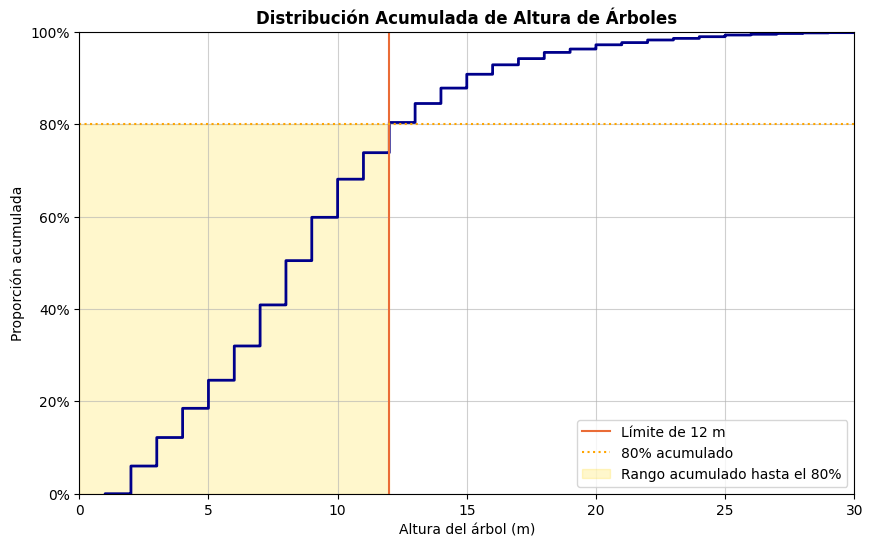

In [24]:
limite_superior = 12
proporcion_hipotesis = 0.80

# Cálculo del percentil 80 real
altura_p80 = np.percentile(copiaDataset["altura_arbol"].dropna(), 80)

plt.figure(figsize=(10, 6))

# crear el Gráfico de Distribución Acumulada (CDF)
sns.ecdfplot(data=copiaDataset, x='altura_arbol', color='darkblue', linewidth=2)

# 2. Resaltar la Hipótesis del 80% (Eje Y)
# La franja va desde 0% hasta el 80%
"""
plt.axhspan(
    ymin=0, 
    ymax=proporcion_hipotesis, 
    color='gold', 
    alpha=0.2, 
    label=f'Rango Acumulado (0% al {proporcion_hipotesis*100:.0f}%)'
)
"""
# Marcar los Límites de la Hipótesis (Eje X, 12 mt)
plt.axvline(x=limite_superior, color="#EA6C36", linestyle='-', linewidth=1.5, label='Límite de 12 m')
# marca los porcentaje en eje Y
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))  # "1" indica que el máximo es 1.0 (100%)

plt.axhline(0.8, color="orange", linestyle=":", label="80% acumulado")
# VER SI AGREGAR O NO linea horz en 80porc

# Sombrear SOLO hasta el percentil 80 
plt.axvspan(
    xmin=0,
    xmax=altura_p80,
    ymin=0,
    ymax=proporcion_hipotesis,
    color='gold',
    alpha=0.20,
    label='Rango acumulado hasta el 80%'
)
#  Ajustar eje X para evitar demasiado espacio
plt.xlim(0, max(30, altura_p80 + 5))

# Etiquetas y título
plt.title("Distribución Acumulada de Altura de Árboles", fontsize=12, fontweight="bold")
plt.xlabel("Altura del árbol (m)")
plt.ylabel("Proporción acumulada")
plt.legend(loc='lower right')
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

Del análisis de la distribución acumulada de alturas se puede ver que el 80% de los árboles alcanza una altura aproximada de 11–12 metros. La línea vertical en 12 m intersecta a la curva acumulada en un valor cercano al 80%, lo que indica que la gran mayoría de los arboles se encuentra por debajo del umbral.

**Por lo tanto, se respalda la hipótesis de que el 80% de los árboles tiene una altura menor a 12 metros.**

### Hipotesis 3
- El ancho de acera (mediana) disponible para el arbolado urbano es superior a 2.5 metros.

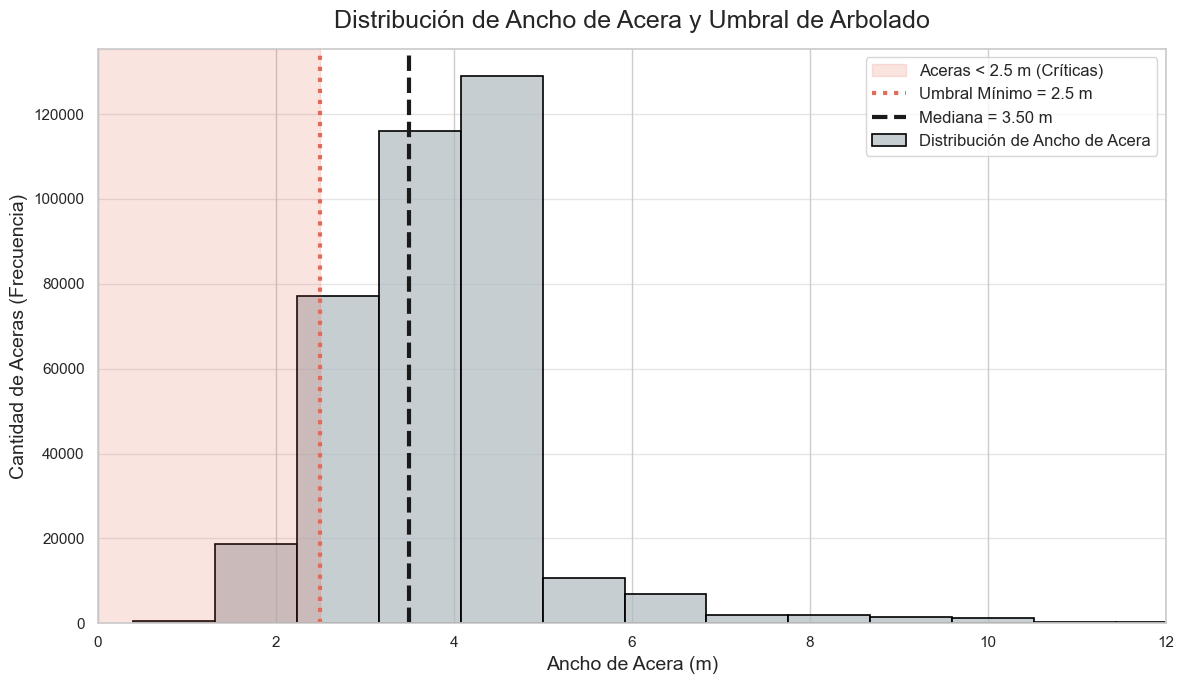

La mediana real de los datos es: 3.50 metros


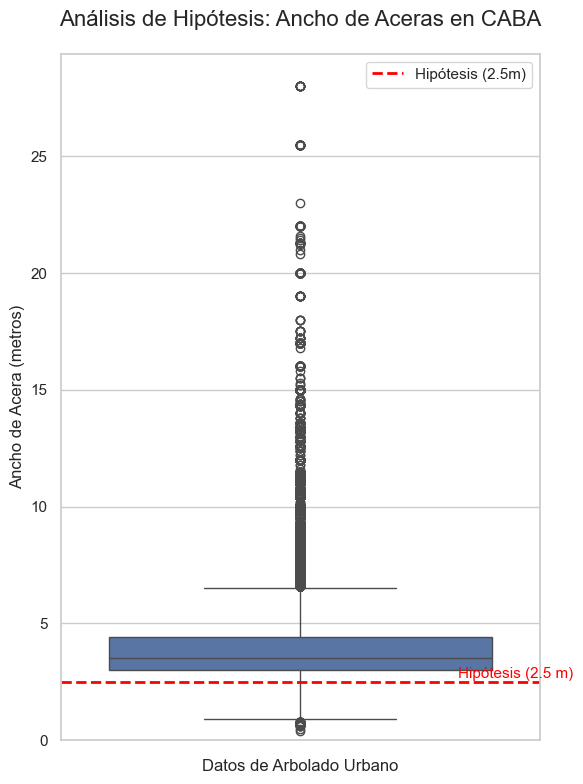

In [31]:
#"La mediana del ancho de las aceras disponibles 
#para el arbolado urbano en la Ciudad de Buenos Aires es superior a 2.5 metros."


datasetH3 = copiaDataset[["ancho_acera"]].copy()

# Reemplaza la coma (,) por el punto (.)
datasetH3['ancho_acera'] = datasetH3['ancho_acera'].str.replace(',', '.')

# Convierte a numérico
datasetH3['ancho_acera'] = pd.to_numeric(datasetH3['ancho_acera'], errors='coerce')


datasetH3["hipotesis_menor_2_5"] = datasetH3["ancho_acera"] < 2.5

# Cantidad de aceras que cumplen la hipótesis
cantidad = datasetH3["hipotesis_menor_2_5"].sum()

# Calcular la mediana
mediana = datasetH3["ancho_acera"].median()

"""
# Histograma
plt.figure(figsize=(10,6))
plt.hist(datasetH3["ancho_acera"], bins=20, color="skyblue", edgecolor="black")
plt.axvline(mediana, color="red", linestyle="dashed", linewidth=2, label=f"Mediana = {mediana:.2f} m")
plt.axvline(2.5, color="green", linestyle="dotted", linewidth=2, label="Umbral = 2.5 m")

plt.xlim(0, 12)
plt.xticks(np.arange(0, 12, 1))

plt.title("Distribución del ancho de acera")
plt.xlabel("Ancho de acera (m)")
plt.ylabel("Cantidad de arboles")
plt.legend()
plt.show() 
"""
#1. 📊 Histograma Mejorado (Distribución y Umbral Crítico)
# -----------------------------------------------------------------

plt.figure(figsize=(12, 7))

# Histograma de la distribución (Se quita el KDE para evitar la distorsión del eje Y)
sns.histplot(
    datasetH3['ancho_acera'].dropna(),
    bins=30,
    color="#AEBAC0",        # Azul claro
    edgecolor='black',      # Borde de la barra más oscuro
    linewidth=1.2,
    alpha=0.7,
    label='Distribución de Ancho de Acera'
)

# Sombreado para resaltar la zona problemática (< 2.5 m)
plt.axvspan(
    0, 2.5,
    color='#E34A33',        # Rojo/Naranja de advertencia
    alpha=0.15,             # Poca opacidad para ver las barras
    label='Aceras < 2.5 m (Críticas)'
)

# Línea del Umbral (2.5 m)
plt.axvline(
    2.5,
    color="#E26B58",        # Rojo/Naranja
    linestyle=':',
    linewidth=3,
    label=f'Umbral Mínimo = 2.5 m'
)

# Línea de la Mediana
plt.axvline(
    mediana,
    color='k',              # Negro
    linestyle='--',
    linewidth=3,
    label=f'Mediana = {mediana:.2f} m'
)

plt.title('Distribución de Ancho de Acera y Umbral de Arbolado', fontsize=18, pad=15)
plt.xlabel('Ancho de Acera (m)', fontsize=14)
plt.ylabel('Cantidad de Aceras (Frecuencia)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.xlim(0, 12) # Limita el eje X hasta 12m para enfocar la distribución principal
plt.tight_layout()
plt.show()

#"La mediana del ancho de las aceras disponibles 
#para el arbolado urbano en la Ciudad de Buenos Aires es superior a 2.5 metros."

datasetH3 = copiaDataset[["ancho_acera"]].copy()

# Reemplaza la coma (,) por el punto (.)
datasetH3['ancho_acera'] = datasetH3['ancho_acera'].str.replace(',', '.')

# Convierte a numérico
datasetH3['ancho_acera'] = pd.to_numeric(datasetH3['ancho_acera'], errors='coerce')

# 2. CALCULAR LA MEDIANA REAL (PARA VERIFICAR)
mediana_real = datasetH3['ancho_acera'].median()
print(f"La mediana real de los datos es: {mediana_real:.2f} metros")

# 3. CREAR EL GRÁFICO
valor_hipotesis = 2.5

# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")

# Crear la figura
plt.figure(figsize=(6, 8)) # Altura (8) mayor que ancho (6) para un boxplot vertical

# Dibujar el Box Plot
ax = sns.boxplot(y=datasetH3['ancho_acera'])

# --- ESTA ES LA PARTE CLAVE ---
# Dibujar la línea horizontal roja que representa la hipótesis
plt.axhline(
    y=valor_hipotesis,          # Posición Y en 2.5 metros
    color='red',                # Color de la línea
    linestyle='--',             # Estilo de línea (punteada)
    linewidth=2,                # Grosor
    label=f'Hipótesis ({valor_hipotesis}m)' # Etiqueta
)

# Añadir un texto claro junto a la línea
plt.text(
    x=0.45,                     # Posición X (un poco a la derecha)
    y=valor_hipotesis + 0.05,   # Un poco arriba de la línea
    s=f'Hipótesis (2.5 m)',     # El texto a mostrar
    color='red',                
    va='bottom',                # Alineación vertical
    ha='center',                # Alineación horizontal
    fontsize=11
)
# --- FIN DE LA PARTE CLAVE ---


# 4. PERSONALIZAR TÍTULOS Y ETIQUETAS
plt.title('Análisis de Hipótesis: Ancho de Aceras en CABA', fontsize=16, pad=20)
plt.ylabel('Ancho de Acera (metros)', fontsize=12)
plt.xlabel('Datos de Arbolado Urbano', fontsize=12)

# Asegurarse de que el eje Y muestre bien nuestros valores
plt.ylim(bottom=0) # Que el eje Y empiece en 0

# Mostrar la leyenda (aunque el texto ya es claro)
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()



ANALISIS BIVARIADO

Existe una relación positiva significativa entre la altura del arbol y su cercania al Rio de la Plata.

Formas de plantear la distancia: 
1. tomamos un punto de referencia del rio (ej a la altura de caba)
2. tomamos diferentes puntos a lo largo del rio (da valores mas reales)

Elegimos la opcion 2.
Para elegir estos puntos tenemos en cuenta las comunas que limitan al rio (1,2,4,13 y 14) y elegimos un punto de la costa del rio aleatorio de cada una de ellas.
Comuna 1. Puerto Madero (34°36'25.1"S 58°20'44.9"W)
Comuna 2. Recoleta (34°34'30.2"S 58°23'15.0"W)
Comuna 13. Belgrano (34°32'51.6"S 58°25'50.0"W)
Comuna 14. Palermo (34°33'23.9"S 58°24'37.0"W)

long y lat: Vemos que hay muchos nulos y que no se encuentran en comunas especificas. 
Por lo tanto vamos a cambiarles los valores por: la combinacion de calle_nombre y calle_altura o el numero de manzana
Segun wikipedia:
Comuna 1.  (34°36′00″S 58°23′13″O)
Comuna 2. (34°35′26″S 58°23′26″O)
Comuna 3. (34°36′10″S 58°23′48″O)
Comuna 4. (34°39′01″S 58°25′28″O)
Comuna 5. (34°37′23″S 58°24′45″O)
Comuna 6. (34°37′00″S 58°27′00″O)
Comuna 7. (34°37′49″S 58°28′02″O)
Comuna 8. (34°41′09″S 58°27′20″O)
Comuna 9. (34°39′00″S 58°29′00″O)
Comuna 10. (34°37′55″S 58°29′01″O)
Comuna 11. (34°36′32″S 58°30′59″O)
Comuna 12. (34°34′07″S 58°28′58″O)
Comuna 13. (34°33′13″S 58°27′50″O)
Comuna 14. (34°35′20″S 58°25′50″O)
Comuna 15. (34°35′14″S 58°26′28″O)

In [27]:


#copiaDataset.loc[copiaDataset["long"].isna(), "comuna"].unique()



lat_map = {
    1 : -34.36,
    2 : -34.35,
    3 : -34.36,
    4 : -34.39,
    5 : -34.37,
    6 : -34.37,
    7 : -34.37,
    8 : -34.41,
    9 : -34.39,
    10 : -34.37,
    11 : -34.36,
    12 : -34.34,
    13 : -34.33,
    14 : -34.35,
    15 : -34.35,
}
long_map = {
    1 : -58.23,
    2 : -58.23,
    3 : -58.23,
    4 : -58.25,
    5 : -58.24,
    6 : -58.27,
    7 : -58.28,
    8 : -58.27,
    9 : -58.29,
    10 : -58.29,
    11 : -58.30,
    12 : -58.28,
    13 : -58.27,
    14 : -58.25,
    15 : -58.26,
}

#usamos copiaDataset u otro nuevo?
#Crea una columna virtual que tiene el valor de latitud correspondiente a la comuna de cada fila
#Despues toma la columna virtual como valor para lat
#copiaDataset["lat"] = copiaDataset["lat"].fillna(copiaDataset["comuna"].map(lat_map))
#copiaDataset["long"] = copiaDataset["long"].fillna(copiaDataset["comuna"].map(long_map))

#ya hicimos el preprocesamiento, ahora el analisis de las distancias

coords = [
    (-34.36,-58.20), #Puerto Madero
    (-34.34,-58.23), #Recoleta
    (-34.32,-58.25), #Belgrano
    (-34.33,-58.24), #Palermo
]

#datasetH4 = copiaDataset[["altura_arbol","lat","long"]].copy()

# Transformamos la lista de (lat, long) a (long, lat) para Shapely/Geopandas
#coords_rio_shapely = [(lon, lat) for lat, lon in coords]

# 1. Crear el GeoDataFrame de tus Puntos (Árboles)
#Crea el contenedor(datasetH4), le dice a GeoPandas cuáles columnas(long y lat) representan la ubicación de cada fila.
#Le dice a la computadora el sistema de coordenadas que estás usando.
#puntos = gpd.GeoDataFrame(
    #datasetH4, 
    #geometry=gpd.points_from_xy(datasetH4.long, datasetH4.lat),
    #crs="EPSG:4326"
#)
#2. Crea la Línea del Río (LineString) a partir de los 4 puntos
#linea_rio = LineString(coords_rio_shapely)

# Proyectamos todo a EPSG:32721 (UTM zone 21S), que usa el metro.
#CRS_METROS = "EPSG:32721"

# 1. Proyecta los puntos del dataset a metros
#gdf_puntos_metros = puntos.to_crs(CRS_METROS)
# 2. Proyecta la línea del río a metros
#linea_rio_metros = linea_rio.to_crs(CRS_METROS)


# 1. Aplicamos .distance() sobre los objetos proyectados.
# La sintaxis de GeoPandas con una sola geometría requiere envolverla en un GeoSeries
#gds_linea_metros = gpd.GeoSeries([linea_rio_metros])

#distancias_en_metros = gdf_puntos_metros.distance(gds_linea_metros.iloc[0])

# 2. Asignar el resultado al DataFrame original
#datasetH4['distancia_rio_metros'] = distancias_en_metros

#print(datasetH4)


Conteo usando método .loc:
buen_estado
1    331014
0     39166
Name: count, dtype: int64
--- Porcentaje de Buen y Mal Estado de Planteras por Comuna ---
buen_estado  Mal Estado (%)  Buen Estado (%)  Total Planteras
comuna                                                       
1                      5.73            94.27            12723
2                      8.25            91.75             7115
3                      3.48            96.52            13320
4                      6.66            93.34            32346
5                      9.06            90.94            15224
6                      8.61            91.39            15591
7                      9.60            90.40            25608
8                      9.34            90.66            21978
9                     11.83            88.17            36405
10                    14.32            85.68            33421
11                    14.05            85.95            37340
12                    12.31            87

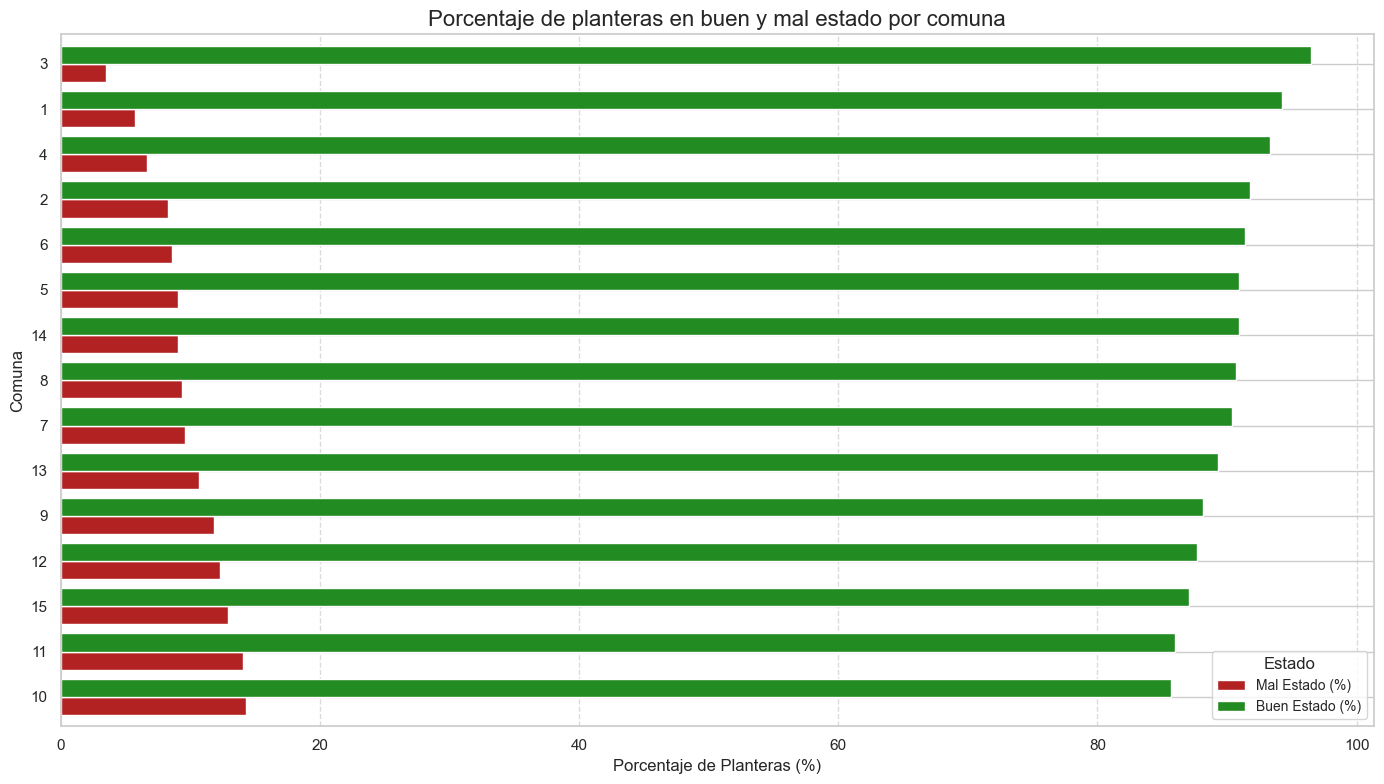

In [28]:
#Existe una asociacion entre la comuna donde se encuentra el arbol y el estado de la plantera."

datasetH4= copiaDataset[["comuna","estado_plantera"]].copy()
datasetH4["buen_estado"] = 0

m_estado = (
    (datasetH4["estado_plantera"]== "subocupada")|
    (datasetH4["estado_plantera"]=="parcialmente cerrada") |
    (datasetH4["estado_plantera"]=="sobreocupada") | 
    (datasetH4["estado_plantera"]=="vacía")
)
datasetH4.loc[m_estado, "buen_estado"] = 0

b_estado = (
    (datasetH4["estado_plantera"]=="ocupada") | 
    (datasetH4["estado_plantera"]=="cerrada")
)

datasetH4.loc[b_estado, "buen_estado"] = 1
print("Conteo usando método .loc:")
print(datasetH4["buen_estado"].value_counts())

#obtenemos los porcentajes de buen y mal estado de las planteras por comuna

conteo_por_estado = datasetH4.groupby(["comuna", "buen_estado"]).size().reset_index(name="conteo")

# Calcula el total de planteras por cada comuna para el porcentaje
total_por_comuna = datasetH4.groupby("comuna").size().reset_index(name="total_comuna")

# 2. Combinar y calcular el porcentaje
resultados = pd.merge(conteo_por_estado, total_por_comuna, on="comuna")

resultados["porcentaje"] = (resultados["conteo"] / resultados["total_comuna"]) * 100

# 3. Pivote para una mejor visualización
# Transforma la tabla para que los estados (0 y 1) sean columnas
resultados_comuna = resultados.pivot(
    index="comuna", 
    columns="buen_estado", 
    values="porcentaje"
).fillna(0).rename(columns={0: "Mal Estado (%)", 1: "Buen Estado (%)"})

# 4. (Opcional) Agregar el conteo total de planteras por comuna
resultados_comuna["Total Planteras"] = total_por_comuna.set_index("comuna")["total_comuna"]

# Mostrar el resultado final
print("--- Porcentaje de Buen y Mal Estado de Planteras por Comuna ---")
print(resultados_comuna.round(2))

df_grafico = resultados_comuna.drop(columns=["Total Planteras"])

# Reordenar las comunas por el porcentaje de Mal Estado (para ver las peores comunas primero)
df_grafico = df_grafico.sort_values(by="Mal Estado (%)", ascending=False)

# 2. Configurar el gráfico
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Usar el método plot de Pandas/Matplotlib para crear el gráfico de barras
# kind='barh' para barras horizontales, que son mejores para muchas categorías (comunas)
df_grafico.plot(
    kind="barh", 
    ax=ax, 
    color={"Buen Estado (%)": "forestgreen", "Mal Estado (%)": "firebrick"},
    width=0.8 # Ancho de las barras
)

# 3. Personalizar el gráfico
plt.title("Porcentaje de planteras en buen y mal estado por comuna", fontsize=16)
plt.xlabel("Porcentaje de Planteras (%)", fontsize=12)
plt.ylabel("Comuna", fontsize=12)
plt.legend(title="Estado", loc="lower right", fontsize=10)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout() # Asegura que las etiquetas no se corten

plt.show()

    comuna    region  prop_platanus
0        1   noreste       0.119311
1        2   noreste       0.098384
2        3   sudeste       0.049550
3        4   sudeste       0.070828
4        5   sudeste       0.115738
5        6   sudeste       0.066577
6        7   sudeste       0.070993
7        8  sudoeste       0.043544
8        9  sudoeste       0.072105
9       10  sudoeste       0.076359
10      11  noroeste       0.109588
11      12  noroeste       0.069658
12      13   noreste       0.081062
13      14   noreste       0.153232
14      15  noroeste       0.135262

--- PRUEBA DE LEVENE (Homocedasticidad) ---
Estadístico de Levene: 0.3861
p-value: 0.7652
NO se rechaza la hipótesis nula: LAS VARIANZAS SON IGUALES

--- PRUEBA DE NORMALIDAD (Shapiro-Wilk en residuos) ---
Estadístico de Shapiro-Wilk: 0.9498
p-value: 0.5212
NO se rechaza la hipótesis nula: LOS RESIDUOS SIGUEN DISTRIBUCIÓN NORMAL


C:\Users\Eliana\AppData\Local\Temp\ipykernel_3840\1935641667.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([datos_por_region[region] for region in regiones], labels=regiones)


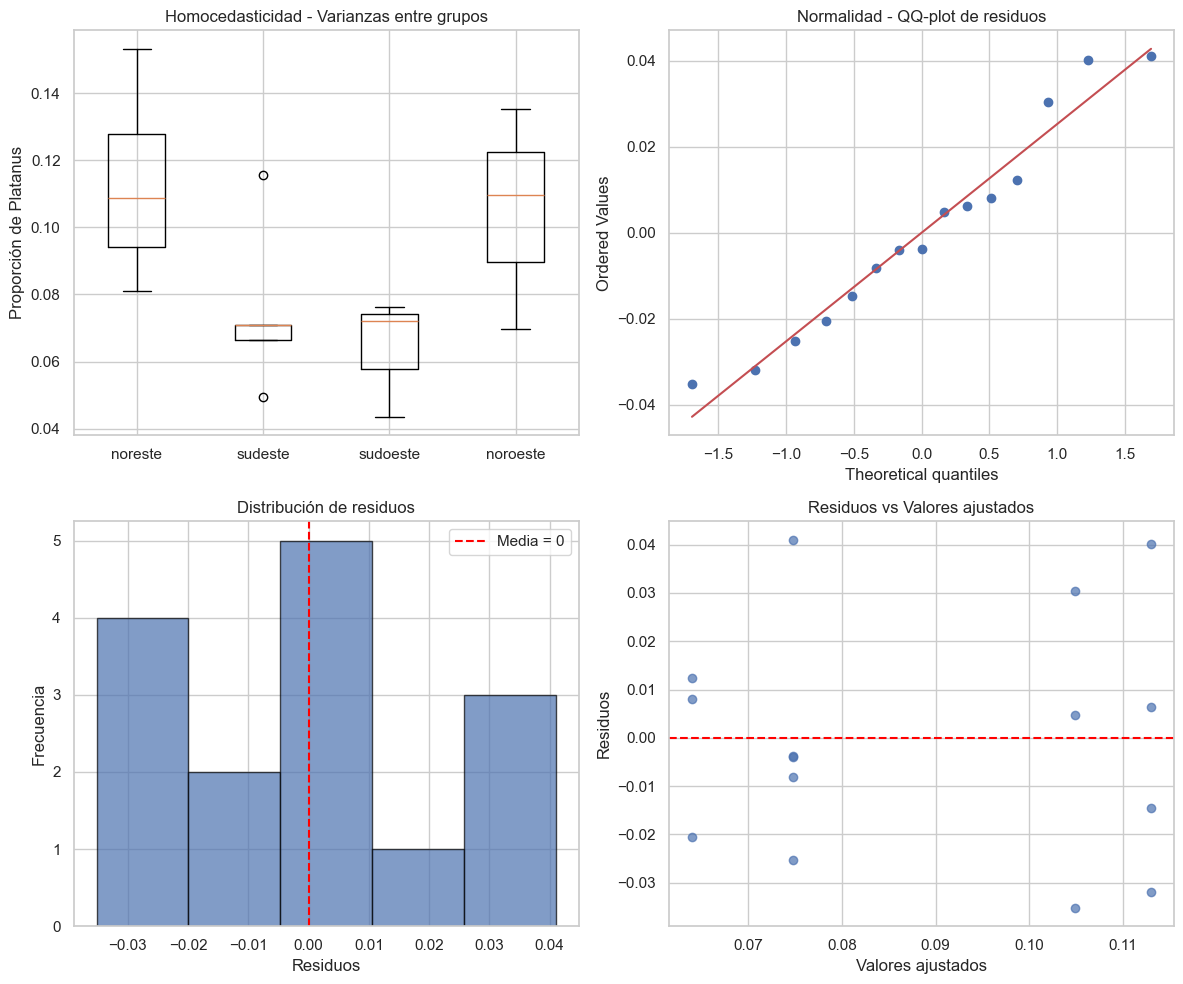

Estadístico F: 2.6834
p-value: 0.0982
0.09818659929937514
Resultado NO significativo: No hay diferencias entre regiones


In [29]:
#"Existen regiones con mayor proporcion de Platanus x acerifolia, especie que produce alergias"

#H0:las proporciones de Platanus x acerifolia son iguales en todas las regiones
#H1: existen diferencias en la proporción de Platanus x acerifolia entre las regiones.

datasetH5 = copiaDataset[["comuna","nombre_cientifico"]].copy()

#planteamos cuatro grupos: noreste,sureste,noroeste,sudoeste
mapeo_regiones={
    1 : "noreste",
    2 : "noreste",
    3 : "sudeste",
    4 : "sudeste",
    5 : "sudeste",
    6 : "sudeste",
    7 : "sudeste",
    8 : "sudoeste",
    9 : "sudoeste",
    10 : "sudoeste",
    11 : "noroeste",
    12 : "noroeste",
    13 : "noreste",
    14 : "noreste",
    15 : "noroeste",
}
datasetH5["region"]=datasetH5["comuna"].map(mapeo_regiones)
datasetH5["es_platanus"] = datasetH5["nombre_cientifico"].str.contains("platanus", case =False,na=False)


proporcion = datasetH5.groupby(["comuna", "region"]).agg(
    prop_platanus=("es_platanus", "mean")  # "mean" de booleanos es la proporción
).reset_index()

print(proporcion)

regiones = proporcion['region'].unique()
datos_por_region = {}

for region in regiones:
    datos_por_region[region] = proporcion[proporcion['region'] == region]['prop_platanus'].values

# 2. Verificar HOMOCEDASTICIDAD (igualdad de varianzas) - Test de Levene
print("\n--- PRUEBA DE LEVENE (Homocedasticidad) ---")
levene_stat, levene_p = levene(*datos_por_region.values())
print(f"Estadístico de Levene: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")

if levene_p > 0.05:
    print("NO se rechaza la hipótesis nula: LAS VARIANZAS SON IGUALES")
    homocedasticidad = True
else:
    print("SE RECHAZA la hipótesis nula: LAS VARIANZAS NO SON IGUALES")
    homocedasticidad = False

# 3. Verificar NORMALIDAD - Test de Shapiro-Wilk en los residuos
print("\n--- PRUEBA DE NORMALIDAD (Shapiro-Wilk en residuos) ---")

# Calcular residuos (diferencia entre cada valor y la media de su grupo)
residuos = []
for idx, row in proporcion.iterrows():
    region = row['region']
    media_region = np.mean(datos_por_region[region])
    residuo = row['prop_platanus'] - media_region
    residuos.append(residuo)

residuos = np.array(residuos)

# Test de Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residuos)
print(f"Estadístico de Shapiro-Wilk: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("NO se rechaza la hipótesis nula: LOS RESIDUOS SIGUEN DISTRIBUCIÓN NORMAL")
    normalidad = True
else:
    print("SE RECHAZA la hipótesis nula: LOS RESIDUOS NO SIGUEN DISTRIBUCIÓN NORMAL")
    normalidad = False

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1: Boxplot por región (homocedasticidad)
axes[0, 0].boxplot([datos_por_region[region] for region in regiones], labels=regiones)
axes[0, 0].set_title('Homocedasticidad - Varianzas entre grupos')
axes[0, 0].set_ylabel('Proporción de Platanus')

# Gráfico 2: QQ-plot de residuos (normalidad)
stats.probplot(residuos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normalidad - QQ-plot de residuos')

# Gráfico 3: Histograma de residuos
axes[1, 0].hist(residuos, bins=5, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--', label='Media = 0')
axes[1, 0].set_title('Distribución de residuos')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend()

# Gráfico 4: Residuos vs Valores ajustados
valores_ajustados = [np.mean(datos_por_region[row['region']]) for idx, row in proporcion.iterrows()]
axes[1, 1].scatter(valores_ajustados, residuos, alpha=0.7)
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('Residuos vs Valores ajustados')
axes[1, 1].set_xlabel('Valores ajustados')
axes[1, 1].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

#tanto el p valor del test de levene como de shapiro nos dio >0,05, 
# por lo tanto se cumplen los supuestos de ANOVA y podemos hacer el test parametrico

# ANOVA paramétrico
anova_result = stats.f_oneway(*[datos_por_region[region] for region in regiones])
print(f"Estadístico F: {anova_result.statistic:.4f}")
print(f"p-value: {anova_result.pvalue:.4f}")

print(anova_result.pvalue)
print("Resultado NO significativo: No hay diferencias entre regiones")

#que podemos decir ademas de que no hay diferencias significativas?
#mostramos la region con mayor proporcion igualmente?



In [30]:
#La tasa de daño a la infraestructura (rotura de veredas) no se distribuye aleatoriamente, 
# sino que es significativamente mayor en aquellas comunas que presentan una alta densidad de 
# especies de arbolado específicas en aceras angostas.

copiaDataset["nombre_cientifico"].value_counts()

nombre_cientifico
fraxinus pennsylvanica    133609
platanus x acerifolia      32319
ficus benjamina            22508
tilia x moltkei            15605
melia azedarach            14908
                           ...  
juglans mandshurica            1
osmanthus fragrans             1
sterculia monosperma           1
ficus microcarpa               1
ilex cornuta                   1
Name: count, Length: 427, dtype: int64